## Scipygraph

Working with graphs:

We have a module named scipy.sparse.csgraph


## Adjacency matrix : 
n * n matrix where n is no of elements in graph



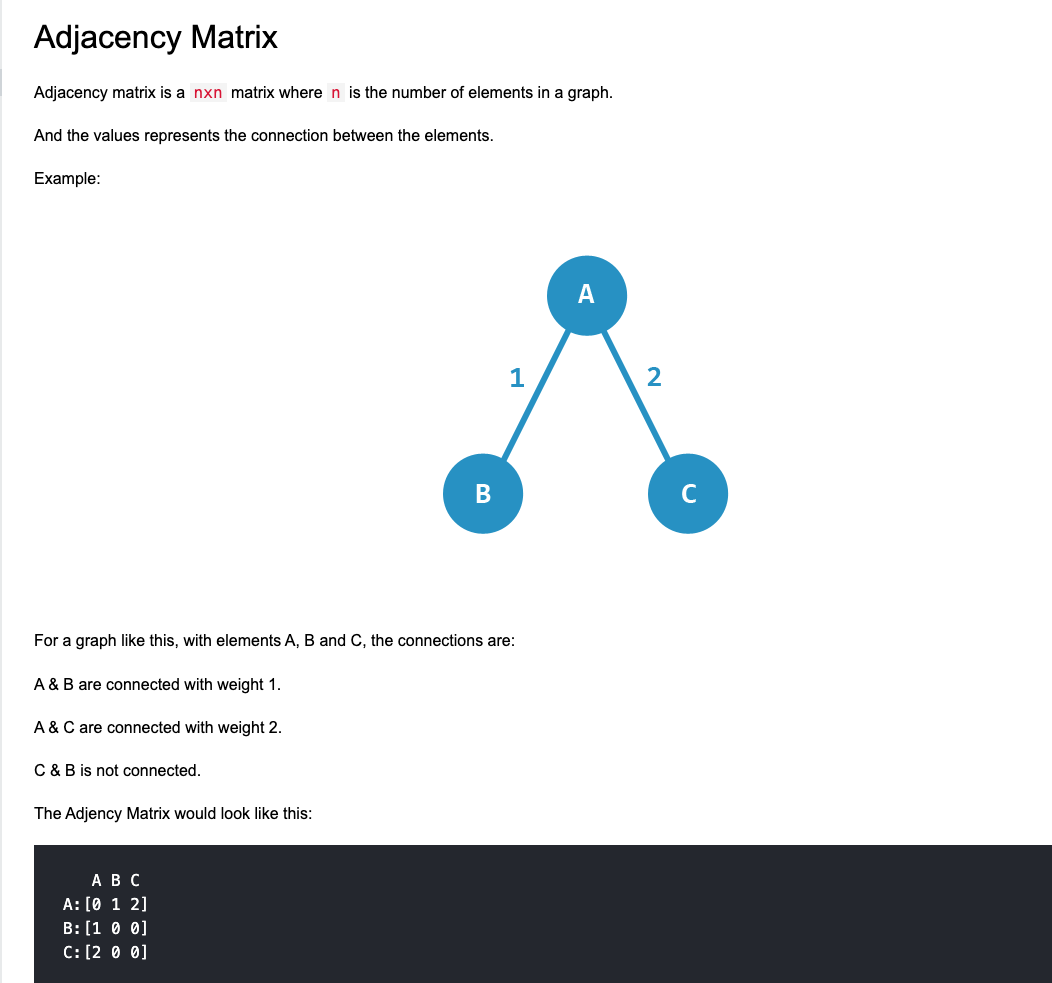

In [6]:
import numpy as np
from scipy.sparse.csgraph import connected_components
from scipy.sparse import csr_matrix
## Find all of the connected components with the connected_components() method.
arr=np.array([
    [0,1,2],
    [1,0,0],
    [2,0,0]
])

newarr=csr_matrix(arr)
print(connected_components(newarr))

(1, array([0, 0, 0], dtype=int32))


## Dijkstra
Use the dijkstra method to find the shortest path in a graph from one element to another.

It takes following arguments:

return_predecessors: boolean (True to return whole path of traversal otherwise False).

indices: index of the element to return all paths from that element only.

limit: max weight of a path.

In [11]:
## Find the shortest paths from source node 0 to all other nodes 
## and also return the predecessor of each node in the shortest-path tree.
import numpy as np
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import dijkstra

arr=np.array([
    [0,1,2],
    [1,0,0],
    [2,0,0]
])

newarr=csr_matrix(arr)

print(dijkstra(newarr,return_predecessors=True,indices=0))

(array([0., 1., 2.]), array([-9999,     0,     0], dtype=int32))


Graphically:

      1
  (1)---(0)
          \
           \ 2
            \
            (2)


array([0., 1., 2.])

These are the shortest distances from node 0:

Destination	Distance
0	0

1	1

2	2

Explanation:

Distance from 0 → 0 = 0

Distance from 0 → 1 = 1 (direct edge)

Distance from 0 → 2 = 2 (direct edge)

array([-9999, 0, 0], dtype=int32)

This is the predecessor array.

For each node, it tells you which node comes immediately before it on the shortest path from the source.

Node	Predecessor
0	-9999

1	0

2	0

Why is node 0's predecessor -9999?

-9999

is a special value meaning:

"No predecessor exists."

Since node 0 is the source node, nothing comes before it.

In [12]:
## Floyd Warshall
## Use the floyd_warshall() method to find shortest path between all pairs of elements.

import numpy as np
from scipy.sparse.csgraph import floyd_warshall
from scipy.sparse import csr_matrix

arr=np.array([
    [0,1,2],
    [1,0,0],
    [2,0,0]
])

newarr=csr_matrix(arr)
print(floyd_warshall(newarr,return_predecessors=True))

(array([[0., 1., 2.],
       [1., 0., 3.],
       [2., 3., 0.]]), array([[-9999,     0,     0],
       [    1, -9999,     0],
       [    2,     0, -9999]], dtype=int32))


In [17]:
## Bellman Ford
## The bellman_ford() method can also find the shortest path between all pairs of elements, 
## but this method can handle negative weights as well.\


import numpy as np
from scipy.sparse.csgraph import bellman_ford
from scipy.sparse import csr_matrix

arr=np.array([
    [0,-1,2],
    [1,0,0],
    [2,0,0]
])

newarr=csr_matrix(arr)
print(bellman_ford(newarr,return_predecessors=True,indices=0))

(array([ 0., -1.,  2.]), array([-9999,     0,     0], dtype=int32))


## Depth First Order:

The depth_first_order() method returns a depth first traversal from a node.

This function takes following arguments:

1-the graph.

2-the starting element to traverse graph from.


Returns (node_order, predecessors)



In [18]:
import numpy as np
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import depth_first_order

arr = np.array([
  [0, 1, 0, 1],
  [1, 1, 1, 1],
  [2, 1, 1, 0],
  [0, 1, 0, 1]
])

newarr = csr_matrix(arr)
print(depth_first_order(newarr,1))

(array([1, 0, 3, 2], dtype=int32), array([    1, -9999,     1,     0], dtype=int32))


Graph Representation

Nodes: 0, 1, 2, 3

Edges:

0 → 1

0 → 3



1 → 0

1 → 1 (self-loop)

1 → 2

1 → 3



2 → 0

2 → 1

2 → 2 (self-loop)



3 → 1

3 → 3 (self-loop)




depth_first_order(newarr, 1)

The second argument (1) is the starting node.

DFS works by:

Visit node 1.

Go as deep as possible along an unvisited neighbor.

Backtrack when no unvisited neighbors remain.

node_order

The order in which nodes are first visited.

For this graph, typically:

array([1, 0, 3, 2])

predecessors

The DFS tree.

Example:

array([1, -9999, 1, 0])


Start at 1
↓
Visit 0
↓
Visit 3
↓
Backtrack (Go back to 0)
↓
Visit 2

## Breadth First Order:

The breadth_first_order() method returns a breadth first traversal from a node.

This function takes following arguments:

the graph.

the starting element to traverse graph from.

In [19]:
import numpy as np
from scipy.sparse.csgraph import breadth_first_order
from scipy.sparse import csr_matrix

arr = np.array ([
    [0,1,0,1],
    [1,1,1,1],
    [2,1,1,0],
    [0,1,0,1]
]
)

newarr=csr_matrix(arr)

print(breadth_first_order(newarr,1))

(array([1, 0, 2, 3], dtype=int32), array([    1, -9999,     1,     1], dtype=int32))
